# Keith Wampler
# 569 Spring 2026
# Homework 3

The goal of this  homework is to build familiarity with PyTorch and also to practice tuning. Try this using PyTorch, but tensor flow is fine too. 

Change the data set to the cancer file (it's available "from sklearn.datasets import load_breast_cancer")

Write a script to tune a model’s hyperparameters

Test different numbers of hidden layers (1-4) with different widths (10-50 by 10)
Change the base learning rate by +/- 10%
Estimate the number of learned parameters involved with the model
 
Send me your code and a couple of paragraphs describing any patterns in the performance and also a couple of paragraphs describing any tradeoffs in model complexity and model performance

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
import numpy as np
import seaborn as sns

In [11]:
def prepare_data():
    data = load_breast_cancer()
    X = data.data
    y = data.target
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1701, stratify=y)
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)
    
    print(f"Training Tensor Shape: {X_train_t.shape}")
    print(f"Input Dimension (Features): {X_train_t.shape[1]}\n")
    
    return X_train_t, X_test_t, y_train_t, y_test_t

X_train, X_test, y_train, y_test = prepare_data()

Training Tensor Shape: torch.Size([455, 30])
Input Dimension (Features): 30



In [12]:
class DynamicNet(nn.Module):
    def __init__(self, input_size, num_hidden_layers, hidden_width):
        super(DynamicNet, self).__init__()
        
        layers = []
        current_dim = input_size
        
        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(current_dim, hidden_width))
            layers.append(nn.ReLU())
            current_dim = hidden_width
            
        layers.append(nn.Linear(current_dim, 1))
        
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("DynamicNet architecture and parameter counter defined.")

DynamicNet architecture and parameter counter defined.


In [13]:
def tune_hyperparameters(X_train, X_test, y_train, y_test):
    input_size = X_train.shape[1] 
    
    hidden_layers_grid = [1, 2, 3, 4]
    widths_grid = [10, 20, 30, 40, 50]
    
    base_lr = 0.01
    learning_rates = [base_lr * 0.9, base_lr, base_lr * 1.1] 
    
    epochs = 100 
    results = []
    
    best_acc_per_lr = {lr: 0 for lr in learning_rates}
    loss_histories_per_lr = {lr: [] for lr in learning_rates}

    print(f"{'Layers':<8} | {'Width':<7} | {'LR':<7} | {'Params':<8} | {'Test Acc':<8}")
    print("-" * 50)
    
    for layers, width, lr in itertools.product(hidden_layers_grid, widths_grid, learning_rates):
        
        model = DynamicNet(input_size=input_size, num_hidden_layers=layers, hidden_width=width)
        num_params = count_parameters(model)
        
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        
        current_loss_history = []
        
        model.train()
        for epoch in range(epochs):
            optimizer.zero_grad()
            outputs = model(X_train)
            loss = criterion(outputs, y_train)
            loss.backward()
            optimizer.step()
            
            current_loss_history.append(loss.item())
            
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            predictions = torch.round(torch.sigmoid(test_outputs))
            correct = (predictions == y_test).sum().item()
            accuracy = correct / y_test.size(0)
            
        if accuracy > best_acc_per_lr[lr]:
            best_acc_per_lr[lr] = accuracy
            loss_histories_per_lr[lr] = current_loss_history
            
        results.append({
            'layers': layers,
            'width': width,
            'lr': lr,
            'params': num_params,
            'accuracy': accuracy
        })
        
        print(f"{layers:<8} | {width:<7} | {lr:.4f} | {num_params:<8} | {accuracy*100:.2f}%")

    print("\nHyperparameter tuning complete!")
    return pd.DataFrame(results), loss_histories_per_lr

print("Starting grid search...\n")
results_df, loss_histories_per_lr = tune_hyperparameters(X_train, X_test, y_train, y_test)

Starting grid search...

Layers   | Width   | LR      | Params   | Test Acc
--------------------------------------------------
1        | 10      | 0.0090 | 321      | 97.37%
1        | 10      | 0.0100 | 321      | 98.25%
1        | 10      | 0.0110 | 321      | 97.37%
1        | 20      | 0.0090 | 641      | 97.37%
1        | 20      | 0.0100 | 641      | 98.25%
1        | 20      | 0.0110 | 641      | 97.37%
1        | 30      | 0.0090 | 961      | 98.25%
1        | 30      | 0.0100 | 961      | 98.25%
1        | 30      | 0.0110 | 961      | 95.61%
1        | 40      | 0.0090 | 1281     | 97.37%
1        | 40      | 0.0100 | 1281     | 97.37%
1        | 40      | 0.0110 | 1281     | 98.25%
1        | 50      | 0.0090 | 1601     | 98.25%
1        | 50      | 0.0100 | 1601     | 96.49%
1        | 50      | 0.0110 | 1601     | 96.49%
2        | 10      | 0.0090 | 431      | 97.37%
2        | 10      | 0.0100 | 431      | 97.37%
2        | 10      | 0.0110 | 431      | 98.25%
2        

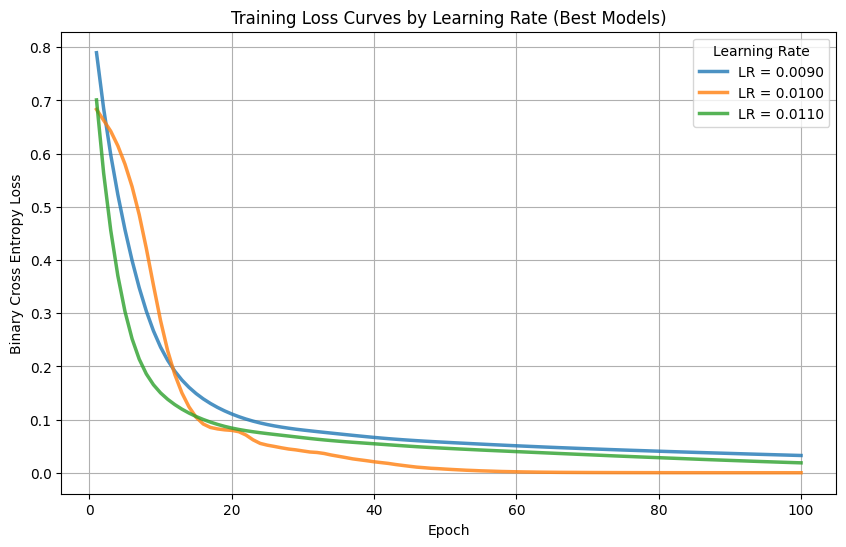

Multi-rate loss curves generated.


In [14]:
plt.figure(figsize=(10, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 

for (lr, history), color in zip(loss_histories_per_lr.items(), colors):
    plt.plot(
        range(1, len(history) + 1), 
        history, 
        color=color, 
        linewidth=2.5, 
        alpha=0.8,
        label=f'LR = {lr:.4f}'
    )

plt.title('Training Loss Curves by Learning Rate (Best Models)')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross Entropy Loss')
plt.legend(title='Learning Rate')
plt.grid(True)
plt.show()

print("Multi-rate loss curves generated.")

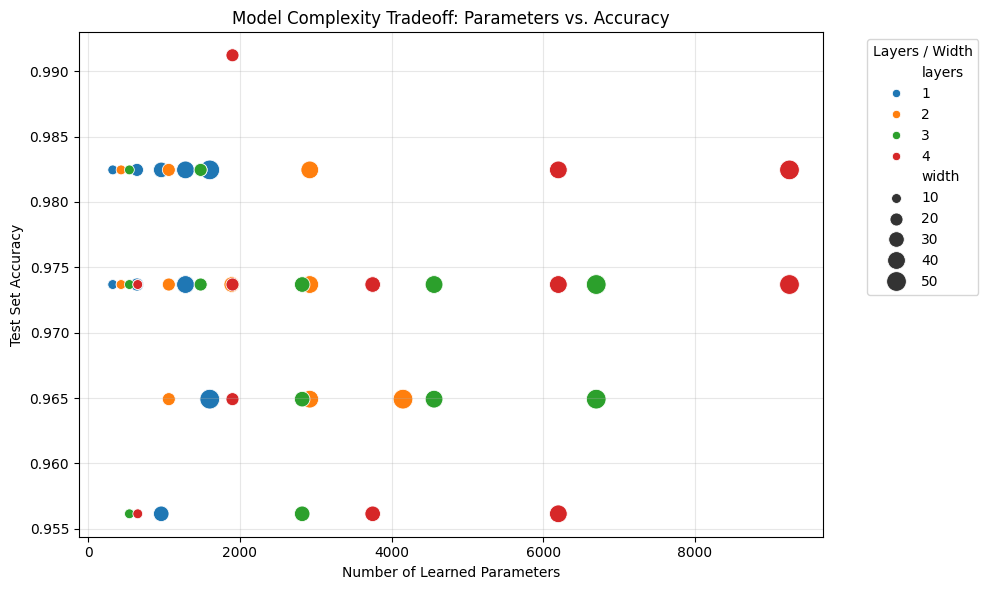

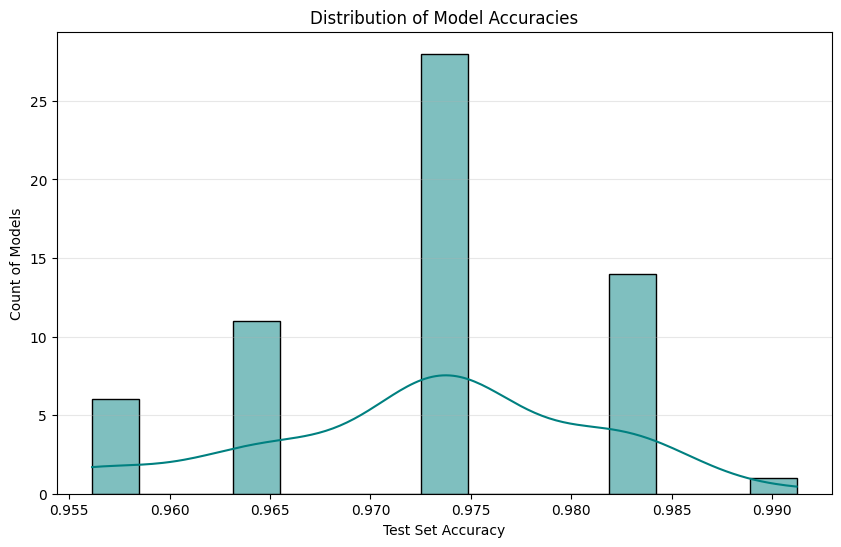

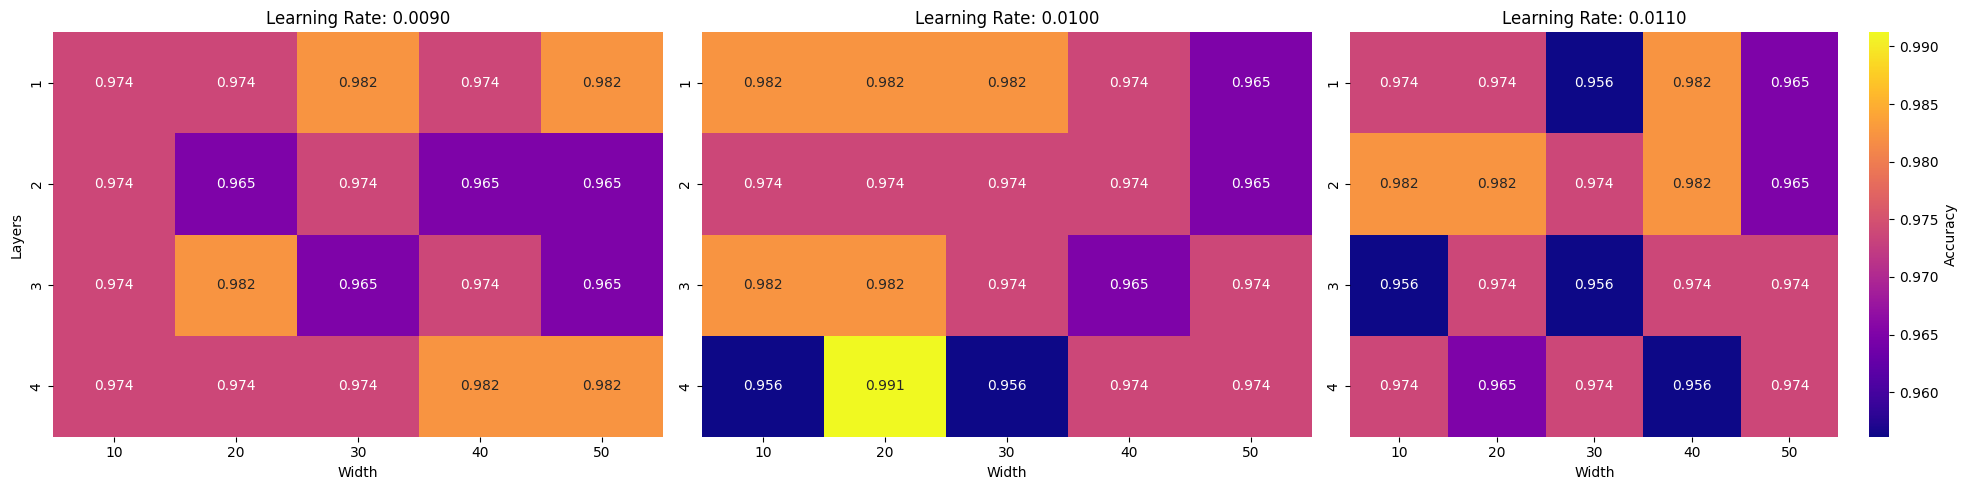

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=results_df, 
    x='params', 
    y='accuracy', 
    hue=results_df['layers'].astype(str), 
    size='width', 
    palette='tab10', 
    sizes=(50, 200)
)
plt.title('Model Complexity Tradeoff: Parameters vs. Accuracy')
plt.xlabel('Number of Learned Parameters')
plt.ylabel('Test Set Accuracy')
plt.grid(True, alpha=0.3)
plt.legend(title='Layers / Width', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(
    data=results_df, 
    x='accuracy', 
    kde=True, 
    color='teal', 
    bins=15
)
plt.title('Distribution of Model Accuracies')
plt.xlabel('Test Set Accuracy')
plt.ylabel('Count of Models')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

learning_rates = sorted(results_df['lr'].unique())
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
vmin, vmax = results_df['accuracy'].min(), results_df['accuracy'].max()

for i, lr in enumerate(learning_rates):
    subset = results_df[abs(results_df['lr'] - lr) < 1e-6]
    pivot = subset.pivot(index='layers', columns='width', values='accuracy')
    
    sns.heatmap(
        pivot, 
        annot=True, 
        fmt=".3f",
        xticklabels=True, 
        yticklabels=True, 
        cmap="plasma", 
        vmin=vmin, 
        vmax=vmax, 
        ax=axes[i], 
        cbar=(i == 2),
        cbar_kws={'label': 'Accuracy'} if i == 2 else {}
    )
    axes[i].set_title(f'Learning Rate: {lr:.4f}')
    axes[i].set_xlabel('Width')
    axes[i].set_ylabel('Layers' if i == 0 else '')

plt.tight_layout()
plt.show()

## Patterns in the Performance

#### The experimental results indicate that the model reaches a performance plateau relatively early. The majority of models cluster at an accuracy of approximately 95.6%, as clearly shown in the bimodal distribution of the histogram. Small adjustments to the learning rate (+/- 10%) did not significantly shift the overall accuracy, suggesting that the Adam optimizer is robust enough to compensate for these minor changes in step size. The heatmaps demonstrate that high-performing pockets (0.965) occur across all three learning rates, but they do not form a consistent trend, indicating that performance at this scale is influenced more by random weight initialization than by specific learning rate tuning.

## Tradeoffs in Model Complexity and Model Performance

#### The scatterplot reveals a clear law of diminishing returns regarding model complexity. As the number of learned parameters increases from roughly 300 to over 9,000, there is no linear correlation with improved accuracy. In fact, the most complex models (4 layers, width 50) often perform identically to, or slightly worse than, simpler models with only 1 or 2 layers. This suggests that the extra structural capacity is redundant for this feature space and likely leads to overfitting on the training data. For this classification task, a smaller, more efficient network (e.g., 2 layers with a width of 30) offers the best tradeoff by providing peak accuracy while minimizing computational overhead and the risk of over-parameterization.